# Mi Primera Red Neuronal

## Cargar Datos

* Se tuvo que descargar todos los tipos de datos de la página `Kaggle`.
* Se descargaron tanto los de entrenamiento como los de prueba.
* Son aproximandamente de 10k cada uno.

***NOTAS***
* También se puede poner `mnist_path = r"C:\Users\PC\OneDrive\Documentos\MNIST"`.

In [1]:
import gzip
import os
from os.path import isfile, join
import numpy as np

### Tener cuidado con el formato de windows
mnist_path = "C:\\Users\\PC\\OneDrive\\Documentos\\MNIST"

def getListFiles(mnist_path : str) -> list:
    return [
        join(mnist_path, file) 
        for file in os.listdir(mnist_path) 
        if isfile(join(mnist_path, file))
    ]

def printListFiles(files):
    for file in files:
        print(file)

files = getListFiles(mnist_path)
printListFiles(files)

C:\Users\PC\OneDrive\Documentos\MNIST\t10k-images.idx3-ubyte.zip
C:\Users\PC\OneDrive\Documentos\MNIST\t10k-labels.idx1-ubyte
C:\Users\PC\OneDrive\Documentos\MNIST\train-images.idx3-ubyte.zip
C:\Users\PC\OneDrive\Documentos\MNIST\train-labels.idx1-ubyte


* Cada imagen descargada, al igual que algunos datasets traen una especie de información suplementaria.
* Empecemos por revisar los datasets de las `images` y de los `labels`.
* Los archivos `MNIST (.idx*-ubyte)` son binarios, no texto. Todos empiezan con un header fijo y luego los datos.
* Recordemos que estas imagenes son 28x28 pixeles todas.
* Es decir podríamos tener fácil un lista de matrices de 28x28.
* ***¿Qué es un número mágico?***
  - Un número mágico (magic number) es un valor fijo que aparece al inicio de un archivo binario.
  - Sirve para identificar el tipo de archivo, verificar que el archivo no esté corrupto y Indicar cómo deben interpretarse los datos.
  - Es como una firma o etiqueta de identidad del archivo.
* Sin el número mágico, no sabrías qué hay dentro ni cómo leerlo.


* `train-labels.idx1-ubyte.`:
  - Ese archivo contiene las etiquetas (`labels`) de las imágenes de entrenamiento del dataset MNIST y sigue el formato IDX, que es binario.
* Este estos archivos seguirian la siguiente forma:
1. Encabezado (8 bytes en total)
   - Para este archivo el `Magic Number Valor: 0x00000801 (en hexadecimal)`.
   - `08 → tipo de dato: unsigned byte` y `01 → 1 dimensión`.
| Bytes | Contenido               | Descripción                   |
| ----- | ----------------------- | ----------------------------- |
| 0–3   | **Magic Number**        | Identifica el tipo de archivo |
| 4–7   | **Número de etiquetas** | Cuántos labels contiene       |

2. Datos (N bytes)
    - Cada etiqueta ocupa 1 byte.
    - Valores posibles: 0 a 9.
    - Cantidad: igual al número indicado en el encabezado (para entrenamiento, normalmente 60,000).

* ***Esquema Visual***.
| Byte 0-3 | Byte 4-7 | Byte 8 ... |
|----------|----------|------------|
| Magic #  |  Count   | Labels     |

* Imagina que tenemos la siguiente información `00000801 0000EA60 05 00 04 01 09 ...`.
  - `EA60 (hex)` = 60000 etiquetas.
  - `05` La primera imagen es un 5 y `00` es un cero.

![ItemsPackageDescription.png](ItemsPackageDescription.png)

```python
import gzip
import zipfile


"""
Devuelve un objeto tipo archivo abierto en binario
compatible con .gz y .zip
"""
def open_mnist_file(file):
    if file.endswith('.gz'):
        return gzip.open(file, 'rb')

    elif file.endswith('.zip'):
        z = zipfile.ZipFile(file)
        inner_file = z.namelist()[0]
        return z.open(inner_file)

    else:
        # Archivos MNIST sin comprimir (.idx*-ubyte)
        return open(file, 'rb')


def getImages(files: list):
    x_train = y_train = x_test = y_test = None

    for file in files:
        with open_mnist_file(file) as data:

            if 'train-images' in file:
                _ = int.from_bytes(data.read(4), 'big')
                num_images = int.from_bytes(data.read(4), 'big')
                rows = int.from_bytes(data.read(4), 'big')
                cols = int.from_bytes(data.read(4), 'big')

                images = data.read()
                x_train = np.frombuffer(images, dtype=np.uint8)
                x_train = x_train.reshape(num_images, rows, cols)

            elif 'train-labels' in file:
                data.read(8)  # magic + num labels
                y_train = np.frombuffer(data.read(), dtype=np.uint8)

            elif 't10k-images' in file:
                _ = int.from_bytes(data.read(4), 'big')
                num_images = int.from_bytes(data.read(4), 'big')
                rows = int.from_bytes(data.read(4), 'big')
                cols = int.from_bytes(data.read(4), 'big')

                images = data.read()
                x_test = np.frombuffer(images, dtype=np.uint8)
                x_test = x_test.reshape(num_images, rows, cols)

            elif 't10k-labels' in file:
                data.read(8)
                y_test = np.frombuffer(data.read(), dtype=np.uint8)

    return x_train, y_train, x_test, y_test
```

## Código Cargar Datos

***NOTAS***
* `gzip solo sirve para archivos .gz, que usan el formato GZIP, no ZIP.`
* Es mejor usar `with zipfile.ZipFile(file, 'r') as z`
* Código original para archivos `gz`.
```python
def getImages(files : list):
    for file in files:
        if 'train-images' in file:
            with gzip.open(file, 'rb') as data:
                _ = int.from_bytes(data.read(4), 'big')
                num_images = int.from_bytes(data.read(4), 'big')
                rows = int.from_bytes(data.read(4), 'big')
                cols = int.from_bytes(data.read(4), 'big')
                train_images = data.read()
                x_train = np.frombuffer(train_images, dtype=np.uint8)
                x_train = x_train.reshape((num_images, rows, cols))
        elif 'train-labels' in file:
            with gzip.open(file, 'rb') as data:
                train_labels = data.read()[8:]
                y_train = np-frombuffer(train_labels,  dtype=np.uint8)
        if 't10k-images' in file:
            with gzip.open(file, 'rb') as data:
                _ = int.from_bytes(data.read(4), 'big')
                num_images = int.from_bytes(data.read(4), 'big')
                rows = int.from_bytes(data.read(4), 'big')
                cols = int.from_bytes(data.read(4), 'big')
                test_images = data.read()
                x_test = np.frombuffer(test_images, dtype=np.uint8)
                x_test = x_train.reshape((num_images, rows, cols))
        elif 't10k-labels' in file:
            with gzip.open(file, 'rb') as data:
                test_labels = data.read()[8:]
                y_test = np-frombuffer(test_labels,  dtype=np.uint8)
    return x_train, y_train, x_test, x_test
```

In [2]:
import gzip
import zipfile
import numpy as np
from contextlib import contextmanager


@contextmanager
def open_mnist_file(path: str):
    """
    Abre archivos MNIST en formato:
    - .gz
    - .zip
    - sin comprimir (.idx*-ubyte)
    Devuelve un stream binario.
    """
    if path.endswith(".gz"):
        f = gzip.open(path, "rb")
        try:
            yield f
        finally:
            f.close()

    elif path.endswith(".zip"):
        zf = zipfile.ZipFile(path)
        try:
            inner_name = zf.namelist()[0]
            with zf.open(inner_name) as f:
                yield f
        finally:
            zf.close()

    else:
        with open(path, "rb") as f:
            yield f


def _read_int32_be(f) -> int:
    """Lee un entero de 32 bits big-endian."""
    return int.from_bytes(f.read(4), byteorder="big")


def _read_images(f):
    """Lee un archivo idx3-ubyte (imágenes)."""
    _ = _read_int32_be(f)          # magic number
    num_images = _read_int32_be(f)
    rows = _read_int32_be(f)
    cols = _read_int32_be(f)

    data = f.read()
    images = np.frombuffer(data, dtype=np.uint8)
    return images.reshape(num_images, rows, cols)


def _read_labels(f):
    """Lee un archivo idx1-ubyte (labels)."""
    _ = _read_int32_be(f)  # magic number
    _ = _read_int32_be(f)  # número de labels
    return np.frombuffer(f.read(), dtype=np.uint8)


def getImages(files: list[str]):
    x_train = y_train = x_test = y_test = None

    for path in files:
        with open_mnist_file(path) as f:

            if "train-images" in path:
                x_train = _read_images(f)

            elif "train-labels" in path:
                y_train = _read_labels(f)

            elif "t10k-images" in path:
                x_test = _read_images(f)

            elif "t10k-labels" in path:
                y_test = _read_labels(f)

    return x_train, y_train, x_test, y_test

## Varaibles con nuestros datos

In [3]:
x_train_num, y_train_num, x_test_num, y_test_num = getImages(files)

In [4]:
print(x_train_num.shape)
print(y_train_num.shape)
print(x_test_num.shape)
print(y_test_num.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


## Graficar una imagen cualquiera

La imagen mostrada corresponde a un : 3


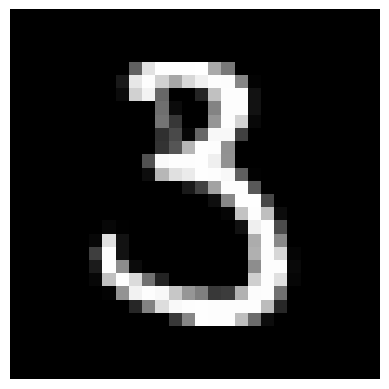

In [5]:
import matplotlib.pyplot as plt

def plot_number(image):
    plt.imshow(image.squeeze(), cmap=plt.get_cmap('gray'))
    plt.axis('off')

rand_idx = np.random.randint(len(y_test_num))
print(f'La imagen mostrada corresponde a un : {y_test_num[rand_idx]}')
plot_number(x_test_num[rand_idx])

## Convertir nuestras imagenes en vectores y a tipo float32.

* ***¿Por qué convertirlos a un arreglo?***
  - Los modelos de `machine learning` y `deep learning` no trabajan directamente con archivos binarios.
  - Operan sobre tensores o arreglos numéricos.
* Convertirlos a un arreglo permite:
  - Acceder a cada píxel.
  - Aplicar operaciones matemáticas.
  - Alimentar los datos a librerías como TensorFlow o PyTorch.

* ***¿Por qué convertirlos a float32?***
  - Aunque los píxeles vienen como enteros (`uint8`), ***los modelos no entrenan bien con enteros***.
  - Las operaciones internas usan números reales, como Derivadas, Calculos etc.
  - ***Estas operaciones se definen sobre números de punto flotante, no enteros***.
  - Si no hicieran `.astype(float)` -> `uint8 / 255 = 0  (en muchos casos)`.
  - por división entera → datos inútiles.
* ***Normalización de los datos:***
  - `imagen = imagen / 255.0`.
  - Convierte valores de `[0, 255]` a `[0.0, 1.0]`.
  - Hace el entrenamiento más estable y rápido.

* ***¿Cómo saben que los valores van de 0 a 255?***
  - No es por los colores en abstracto, es por el formato del dataset MNIST.
* `MNIST` está definido así desde su creación:
  - Imágenes en escala de grises.
  - Cada píxel es un `unsigned byte (uint8)`.
  - Un byte = 8 bits → valores entre 0 y 255.
  - ***Esto viene documentado en la especificación oficial del formato idx***.

* ***¿Por qué específicamente float32?***
  - ***Es el estándar en deep learning***.
  - Más rápido que `float64`.
  - Usa menos memoria.
| Tipo        | Memoria   | Precisión      | Uso                    |
| ----------- | --------- | -------------- | ---------------------- |
| float64     | Alta      | Muy alta       | Ciencia / simulaciones |
| **float32** | **Media** | **Suficiente** | **Deep Learning**      |
| float16     | Baja      | Menor          | Optimización avanzada  |

* ***¿Por qué los x son float y los y no?***
  - `x_train (imágenes)` se usan en operaciones matemáticas porque van a multiplicarse por pesos.
  - Por lo tanto necesitan punto ***flotante***.
  - `y_train (etiquetas)` son los números exactos `0, 1, 2, ..., 9`.
  - Por lo tanto no se normalizanya que no son píxeles.
  - Muchas funciones de pérdida esperan enteros.
  - Por eso se dejan como: `int / uint8`.

* ***¿Por qué hacen reshape(50000, -1)?***
  - `MNIST` originalmente es `(60000, 28, 28)`,entonces lo convertimos a `(50000, 784)`.
  - Entonces cada imagen se aplana en un vector.
  - `-1` significa: ***“Calcula automáticamente la dimensión”***.


In [6]:
### Datos de entrenamiento
x_train = x_train_num[:50000].reshape(50000, -1).astype(np.float32)/255
y_train = y_train_num[:50000].reshape(50000, 1)

### Datos de validación (los ultimos 10k)
x_val = x_train_num[50000:].reshape(10000, -1).astype(np.float32)/255
y_val = y_train_num[50000:].reshape(10000, 1)

### Datos de prueba (origialmente ya son 10k, solo se pasaron a vector)
x_test = x_test_num.copy().reshape(10000, -1).astype(np.float32)/255
y_test = y_test_num.copy().reshape(10000, 1)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 784)
(50000, 1)
(10000, 784)
(10000, 1)


## Repaso Marco Teorico

* Como podemos ver cada vector de nosotros tendrá una longuitud de 784 valores.
* Para este modelo contará con 200 neuronas en la primera aunque en la imagen solo se vean 20.
* Nuestra ultima capa debe ser una por cada posible clasificación.
* Es decir en nuestro caso son 10, porque queremos que se clasifiquen en `[1,2,3,4,5,6,7,8,9]`.
* Computacionalmente no nos costea meter los 50'000 datos de golpe, es por eso que debemos crear `mini-batches`.
* Es decir como pequeñas muestras aleatorias, digamos una matriz de `nx784`.
* Generalmente estas muestras suelen ser números potencias de 2, como por ejemplo `16,32,64,128,256 ... etc`.

* ***Proceso a seguir***
* Al ser un modelo multicapa, necesitamos usar una función de activación, en este caso usaremos `ReLU`.
* Nuestro primer valor de `Z_1` estaría dado por:
$$
\begin{aligned}
Z^{1} &= W^{1} \cdot X + b^{1} \\
Z^{1}_{(200,1)} &= W^{1}_{(200,784)} \cdot X_{(784,m)} + b^{1}_{(200,1)}
\end{aligned}
\quad \text{(Ec 0. Primera Red Neuronal)}
$$

* El resultado de esto debe aplicarse la función `ReLU` para que nos de la no-linealidad.
* También para nuestra segunda neurona debemos usar `a` en lugar de nuestros inputs `x`.
$$
\begin{aligned}
ReLU &=\max(0,x) \\
a^{1} &= ReLU(Z^{1}) \\
Z^{2} &= W^{2} \cdot a^{1} + b^{2}
\end{aligned}
$$

* Por ultimo, no oldivemos la función `SoftMax` y su `Loss Function`, que en este caso sería la `X-Entropy`.
$$ \hat{y_i} = \text{SoftMax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$
$$L(y, \hat{y}) = - \sum_{i=1}^{C} y_i \ln(\hat{y}_i)$$
$$L= - \ln(\hat{y}_{correcta})$$



![MarcoTeorico.png](MarcoTeorico.png)

## Create Mini-Batches

* ***Ventajas de minibatches***:
  - Más rápido que batch completo.
  - Menos ruido que SGD puro.
  - Mejor uso de CPU/GPU
  - Es el estándar en `deep learning`.
* `np.arange(total_data)` → crea índices `[0, 1, 2, ..., N-1]`.
* `np.random.shuffle(idxs)` → mezcla esos índices.
* `x = x[idxs], y = y[idxs]` reordena x e y de la misma forma.
* ***Mezclar siempre antes de crear minibatches (cada epoch).***
* ***Deep learning casi siempre usa generadores o iteradores***.

In [7]:
def create_minibatches(batch_size, x, y, shuffle = True):
    '''
    Dim x --> #muestras, 784
    Dim y --> #muestras, 1
    '''
    ### Validamos que empaqueten las dimensiones de X y el y (target).
    assert x.shape[0] == y.shape[0], 'Error en cantidad de muestras'
    total_data = x.shape[0]
    ### Randomizar
    if shuffle:
        idxs = np.arange(total_data)
        np.random.shuffle(idxs)
        x = x[idxs]
        y = y[idxs]
    ### Objeto iterable.
    return ((x[i:i+batch_size], y[i:i+batch_size]) for i in range(0, total_data, batch_size))

## Init Parameters

* Recordemos que cada imagen es `28×28 = 784 píxeles`.
* Receurda que `np.random.randn` genera números aleatorios siguiendo una distribución normal estándar.
* Con media 0 y varianza 1.
* ***Estos valores son aleatorios***.
* Entonces aca `np.random.randn(neurons[0], input_size)`,estamos generando una matriz aleatoria de 200 por 784 registros.
* Por lo tanto, aca `np.zeros((neurons[0], 1))` será un vector de ceros de longuitud `784`.
* Para `Z2`, recordemos que la dimensiones son 10 neuronas clasicadoras, por lo tanto su dimensión es 10 y 200 inputs.
* ***Es decir, cada una recibe 200 activaciones de la capa anterior***.
* ***¿Por qué multiplicar por 0.001?***
  - Esto reduce la varianza de los pesos iniciales.
  - Se busca evitar activaciones demasiado grandes y evitar gradientes inestables al inicio.
  - En redes simples (como esta de 2 capas), se suele usar este `“truco” didáctico`.

* ***¿qué son las técnicas de Xavier o Kaiming He?***
* Las técnicas de `Xavier (Glorot)` y `Kaiming He (He initialization)` son métodos de inicialización de pesos en redes neuronales.
* Su objetivo es evitar que las activaciones y los gradientes exploten o se desvanezcan cuando la red tiene muchas capas.
* Si inicializas los pesos:
  - muy grandes → gradientes explotan.
  - muy pequeños → gradientes se desvanecen.
* Esto hace que la red:
  - no aprenda.
  - aprenda muy lento.
  - sea inestable.
* `Xavier` y `He` ajustan la varianza de los pesos según el número de neuronas conectadas.
* `Xavier`: `W = np.random.randn(n_out, n_in) * np.sqrt(1 / n_in)`
* `He`: `W = np.random.randn(n_out, n_in) * np.sqrt(2 / n_in)`


In [8]:
def init_parameters(input_size : int, neurons: list) -> dict:
    '''
    input_size --> elementos de entrada (Una vector de 784)
    neurons --> list [200,10] con cantidad de neuronas en cada capa
    '''
    W1 = np.random.randn(neurons[0], input_size) * 0.001
    b1 = np.zeros((neurons[0], 1))

    W2 = np.random.randn(neurons[1], neurons[0]) * 0.001
    b2 = np.zeros((neurons[1], 1))
    
    return { 'W1': W1, 'b1':b1, 'W2':W2, 'b2':b2 }

parameters = init_parameters(28*28, [200,10])
print("W1: ", parameters['W1'].shape)
print("b1: ", parameters['b1'].shape)
print("W2: ", parameters['W2'].shape)
print("b2: ", parameters['b2'].shape)

W1:  (200, 784)
b1:  (200, 1)
W2:  (10, 200)
b2:  (10, 1)


## Función Principal Front Propagation

In [9]:
def scores(x, parameters, activation_fcn):
    """
    X tiene la forma (#pixeles, num_samples)
    """
    z1 = parameters['W1'] @ x + parameters['b1']
    ### devuelve resultado de lafunción de activación
    a1 = activation_fcn(z1)
    z2 = parameters['W2'] @ a1 + parameters['b2']
    return z2, z1, a1

## Definición de Funciones matématicas neceserias.

* Ya con lo anterior inicializado, debemos empezar con nuestro `Front Propagation`.
* Recordemos que está parte corresponde a llegar a `Z2` y aplicar `SoftMax` y luego `X-Entropy`.
$$ReLU =\max(0,x)$$
$$ \hat{y_i} = \text{SoftMax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$
$$L(y, \hat{y}) = - \sum_{i=1}^{C} y_i \ln(\hat{y}_i) =  - \ln(\hat{y}_{correcta}) $$

* En Python, `.squeeze()` es un método que se usa principalmente con `numpy (y también en pandas)` para eliminar dimensiones de tamaño 1 en un arreglo o estructura de datos.
* Si tienes un ndarray, `.squeeze()` elimina todos los ejes cuyo tamaño es 1.
* Aquí se elimina la dimensión “extra” de tamaño 1.
```python
a = np.array([[1, 2, 3]])
print(a.shape)        # (1, 3)

b = a.squeeze()
print(b.shape)        # (3,)
```
* ***Puedes indicar qué eje eliminar, siempre que sea de tamaño 1***.
* Si intentas eliminar un eje cuyo tamaño no es 1, Python lanza un error.
```python
a = np.zeros((1, 3, 1))
b = a.squeeze(axis=0)
print(b.shape)        # (3, 1)
```

* ***¿Porque se está usando en este código?***
  - asegurarse de que y tenga la forma correcta para indexar el array probs.
* No es lo mismo `shape=(3,) = [1,2,3]` que `shape=(3,1) = [[1], [2], [3]]`.
```python
y = np.array([[2], [0], [1]])
print(y.shape)            # (3, 1)

y = y.squeeze()
print(y.shape)            # (3,)
```

In [10]:
def relu(x):
    return np.maximum(0,x)

In [11]:
### Softmax regresará la probabilidad de que sea cada elemento.
def softmax(x):
    exp_scores = np.exp(x)
    sum_exp_scores = np.sum(exp_scores, axis = 0)
    probs = exp_scores/sum_exp_scores
    return probs

In [12]:
### Para este modelo, X-Entropy será nuestra Lost Function.
def x_entropy(scores, y, batch_size=64):
    probs = softmax(scores)
    y_hat = probs[y.squeeze(), np.arange(batch_size)]
    cost = np.sum(-np.log(y_hat)) / batch_size
    return probs, cost

In [13]:
### Ejecutamos nuestro Front para obtener Z1 y Z2.
scores1, z1, a1 = scores(x_train[:64].T, parameters, relu)

In [14]:
a1.shape

(200, 64)

## Obtención de las derivadas parciales para BackWard

* Recuerden que nuestro objetivo es calcular:
$$\frac{\partial L}{\partial W^{2}} , \frac{\partial L}{\partial b^{2}}, \frac{\partial L}{\partial W^{1}} , \frac{\partial L}{\partial b^{1}}$$



* Una vez hechas las funciones del `Front`, pasemos con el `Back`, recordemos que lo primero que tenemos es:
$$\frac{\partial L}{\partial z^{2}} = \hat{y_i} - y$$
$$\delta^{2} = \hat{y_i} - y $$

* Ahora calculemos las derivadas parciales de `W2` y `b1`.
$$
\begin{aligned} \\
\frac{\partial L}{\partial W^{2}} &= \frac{\partial L}{\partial z^{2}} \cdot \frac{\partial z^{2}}{\partial W^{2}} \\
\frac{\partial L}{\partial W^{2}} &= \delta^{2} \cdot \frac{\partial z}{\partial W^{2}} \\
\end{aligned}
$$

* Una vez encontrado esto, hay que encontrar que tanto cambia `W2` con respecto a `Z2`. (Regla de la cadena)
$$
\begin{aligned} \\
z^{2} & =  W^{2} \cdot  a^{1} +  b^{2} \\
\frac{\partial z^{2}}{\partial W^{2}} &= a^{1} \\
\frac{\partial L}{\partial W^{2}} &= \delta^{2} \cdot a^{1} \\
\end{aligned}
$$

* Sigamos con el `bias`.
$$
\begin{aligned} \\
\frac{\partial L}{\partial b^{2}} &= \frac{\partial L}{\partial z^{2}} \cdot \frac{\partial z^{2}}{\partial b^{2}} \\
\frac{\partial L}{\partial b^{2}} &= \delta^{2} \cdot \frac{\partial z}{\partial b^{2}} \\
\\
z^{2} & =  W^{2} \cdot  a^{1} +  b^{2} \\
\frac{\partial z^{2}}{\partial b^{2}} &= 1 \\
\frac{\partial L}{\partial b^{2}} &= \delta^{2} \cdot 1 = \delta^{2}\\
\end{aligned}
$$

***AHORA VAYAMOS POR Z1 y a1***
* Ya con las 2 primeras, debemos ahora derivar `L` con forme a `Z1`.
* Recordemos que `a1` aparece en `Z2 = W2 * a1 + b2`-
* Podemos empezar con la función de activación. Es decir queremos esto:
$$\frac{\partial L}{\partial a^{1}} = \frac{\partial L}{\partial z^{2}} \cdot \frac{\partial z^{2}}{\partial a^{1}}$$

* Si derivamos esa formula respecto a `a1`, solo debería quedarnos `W2`.
$$Z^{2} = W^{2} \cdot a^{1} + b^{2}$$
$$\frac{\partial z^{2}}{\partial a^{1}} = W^{2}$$

* Recordemos que la función ReLu está definida así:
$$a^{1} =\max(0,z^{1})$$

* Al final nos quedaría así:
$$
\begin{aligned} \\
\frac{\partial L}{\partial a^{1}} = (W^{2})^{T} \delta^{2}
\end{aligned}
$$

* Ahora hay que encontrar lo que cambia respecto a `Z1`.
$$\frac{\partial L}{\partial z^{1}} = \delta^{1} $$
$$\frac{\partial L}{\partial z^{1}} = \frac{\partial L}{\partial z^{2}} \cdot \frac{\partial z^{2}}{\partial a^{1}} \cdot \frac{\partial a^{1}}{\partial z^{1}}$$

* Entonces su derivada tendrá la siguiente forma, ya que la derivada de una sola incognita es `1`.
$$
\frac{\partial a^{1}}{\partial z^{1}} =
\begin{cases}
1, & z^{1} > 0 \\
0, & z^{1} \le 0
\end{cases}
\quad
$$

* Sustiyudendo los valores
$$\text{ReLU}'(z^{(1)}) =
\begin{cases}
1 & \text{si } z^{(1)} > 0 \\
0 & \text{si } z^{(1)} \le 0
\end{cases}
$$
$$\frac{\partial L}{\partial z^{1}} = \delta^{2} \cdot W^{2} \cdot \frac{\partial a^{1}}{\partial z^{1}}$$

* Esto es un interruptor:
  - `neurona activa` → deja pasar el error.
  - `neurona apagada` → bloquea el error.

* Entonces `delta1` estaría dado como
$$
\delta^{(1)} =
\frac{\partial L}{\partial z^{(1)}} =
\left(W^{(2)}\right)^{T} \delta^{(2)} \odot \text{ReLU}'\left(z^{(1)}\right)
$$

* Para `W1` y `b1`, es parecido a `Z2`, ya que los vamos a sacar de `Z = W * X + b`.
$$
\begin{aligned} \\
\frac{\partial L}{\partial W^{1}} &= \delta^{1} \cdot x^{T} \\
\frac{\partial L}{\partial b^{1}} &= \delta^{1} \\
\end{aligned}
$$



## Código BackWard

* Esta función calcula los gradientes de la loss respecto a todos los parámetros usando backprop.
```python
def backward(probs, x, y, z1, a1, parameters, batch_size=64):
```
* ***¿Qué hace esto?*** `probs[y.squeeze(), np.arange(batch_size)] -= 1`
  - Recordemos que probs es `y_hat`.
  - Entonces como son probabilidades se les resta `1`.
  - Así obtemos el `y_hat - y`, es decir `delta2`.
  - ***Aquí ocurre toda la derivada de softmax + cross-entropy en una sola línea***.

* ***¿No se supone que la derivada de b2 es delta2?***.
  - `Depende de si estás mirando un solo ejemplo o un batch`.
  - Cuando usas un batch, la loss total es el promedio.
  - Por eso se suman y luego se divide por `batch_size`.

* El bias es el mismo para todos los ejemplos.
* Cada ejemplo “empuja” el bias, Hay que juntar todos esos empujes.

* ***¿Por qué a las probabilidades se les resta 1?***
  - Recordemos que `probs` es el resultado de `Softmax`.
  - Es decir `probs_k = y_hat_k = P(clase k)`.
  - Que a su ves sigue el `one-hot encoding`, algo así `y = [0,0,1,0,...]`.
  - A la hora de hacer la derivada, si la clase es correcta se le resta `1` y caso contrario se resta `0` por el `encoding`.
  - Entoncesen el código, directamente restamos para hacer la derivada.

In [15]:
def backward(probs, x, y, z1, a1, parameters, batch_size=64):
    ### un diccionario para guardar los gradientes finales.
    grads = {}

    ### Calculamos el y_hat - y, se lo asignamos a dz2 o delta2.
    probs[y.squeeze(), np.arange(batch_size)] -= 1
    dz2 = probs.copy()

    ### Recordemos que la derivada de L respecto a W2, es delta2 por a1.
    dW2 = dz2 @ a1.T / batch_size

    ### Para b2, correspondía a a1.
    db2 = np.sum(dz2, axis = 1, keepdims=True) / batch_size
    
    ### Esto también es correcto, L respecto a1, W2 * delta2
    da1 = parameters['W2'].T @ dz2

    ### Aplicar la derivada de ReLU, por lo del encendedor.
    dz1 = da1.copy()
    dz1[z1 <= 0] = 0

    dW1 = dz1 @ x
    db1 = np.sum(dz1, axis=1, keepdims = True)

    assert parameters['W1'].shape == dW1.shape, 'W1 no igual forma'
    assert parameters['W2'].shape == dW2.shape, 'W2 no igual forma'
    assert parameters['b1'].shape == db1.shape, 'b1 no igual forma'
    assert parameters['b2'].shape == db2.shape, 'b2 no igual forma'

    grads = {
        'W1' : dW1,
        'b1' : db1,
        'W2' : dW2,
        'b2' : db2
    }
    return grads   

In [16]:
y_hat, cost = x_entropy(scores1, y_train[:64])

In [17]:
y_hat.shape

(10, 64)

In [18]:
grads = backward(y_hat, x_train[:64], y_train[:64], z1, a1, parameters)

## Training

* ***¿Qué métrica representa?***.
  - Representa la `accuracy (exactitud)` o ***porcentaje de aciertos***.

$$
\begin{aligned}
\text{Accuracy} &= \frac{\text{número de predicciones correctas}}{\text{número total de muestras}}
\end{aligned}
$$

* ***¿Por qué no calcular accuracy por batch?***
  - Porque la accuracy se define sobre todo el dataset, no batch a batch. Entonces así:
  - `correct`: cuántas predicciones acertaste en total.
  - `total`: cuántos ejemplos evaluaste

* ***¿Qué es x y y aquí?***
  - `x`: batch de imágenes → (mb_size, 784).
  - `y`: batch de etiquetas → (mb_size,).

* ***¿Por qué minibatches?***.
  - Evitas pasar todo el dataset de golpe.
  - Mantienes consistencia con el entrenamiento.
  - Permite evaluar en `GPU/CPU` sin reventar `RAM`.

* ***¿Qué está pasando?*** `scores2, z1, a1 = scores(x.T, parameters, relu)`
  - Estás ejecutando tu red neuronal de 2 capas.
  - `x.T → (784, mb_size)`.
  - Ejecutamos nuestras formulas de `Z1`, `a1`.
  - La capera de salida sería `Z2 = W2 * a1 + b2`.
  - `scores2` = logits (aún NO probabilidades).

* ***¿Por qué usar logits y no softmax aquí?***
  - `softmax` + `cross-entropy` es más estable numéricamente.
  - Tu función `x_entropy` seguramente hace ambas cosas juntas.

* ***Softmax + Cross-Entropy*** `y_hat, cost = x_entropy(scores2, y, batch_size=len(x))`.
  - `y_hat`: Forma: (10, mb_size) y cada columna suma 1.
  - Por que es una probabilidad de que sea cada uno.
  - `cost`: Pérdida promedio del batch, no se usa para accuracy.

* ***Predicción de la clase***
  - `np.argmax(y_hat, axis=0)`: La clase con mayor probabilidad → decisión final del modelo.
  - Es decir saca la probabilidad mayor.

* ***¿Por qué squeeze()?***
  - A veces `y` viene como: `(mb_size, 1)` y `(1, mb_size)`.
  - `squeeze()` lo convierte a: `(mb_size,)`.

- Finalmente, hacemos el conteo `correct += np.sum(np.argmax(y_hat, axis=0) == y.squeeze())`.

In [26]:
def accuracy(x_data, y_data, mb_size=64):
    correct = 0
    total = 0
    for i, (x,y) in enumerate(create_minibatches(mb_size, x_data, y_data)):
        ### Forward pass
        scores2, z1, a1 = scores(x.T, parameters, relu)
        y_hat, cost = x_entropy(scores2, y, batch_size=len(x))
        
        correct += np.sum(np.argmax(y_hat, axis=0) == y.squeeze())
        total += y_hat.shape[1]
    return correct/total

In [27]:
def train(epochs, parameters, mb_size=64, learning_rate = 1e-3):
    for epoch in range(epochs):
        for i, (x, y) in enumerate(create_minibatches(mb_size, x_train, y_train)):
            scores2, z1, a1 = scores(x.T, parameters=parameters, activation_fcn=relu)
            y_hat, cost = x_entropy(scores2, y, batch_size=len(x))
            grads = backward(
                probs=y_hat,
                x=x,
                y=y,
                z1=z1,
                a1=a1,
                parameters=parameters,
                batch_size=len(x))
            
            parameters['W1'] = parameters['W1'] - learning_rate*grads['W1']
            parameters['b1'] = parameters['b1'] - learning_rate*grads['b1']
            parameters['W2'] = parameters['W2'] - learning_rate*grads['W2']
            parameters['b2'] = parameters['b2'] - learning_rate*grads['b2']
        print(f'Costo es: {cost}, y_accuracy: {accuracy(x_val, y_val, mb_size)}')
    return parameters

In [28]:
mb_size = 512
learning_rate = 1e-2
epochs = 20
parameters= train(epochs=epochs, parameters=parameters, mb_size=mb_size, learning_rate=learning_rate)

Costo es: 0.30594976184286554, y_accuracy: 0.9026
Costo es: 0.3346422131800561, y_accuracy: 0.9148
Costo es: 0.3169440299023172, y_accuracy: 0.9192
Costo es: 0.19120354728754785, y_accuracy: 0.9289
Costo es: 0.2215825023217284, y_accuracy: 0.9326
Costo es: 0.2081535732457088, y_accuracy: 0.9386
Costo es: 0.204922648544961, y_accuracy: 0.9437
Costo es: 0.1764685989261555, y_accuracy: 0.9469
Costo es: 0.1745275843862745, y_accuracy: 0.9513
Costo es: 0.1613057310981239, y_accuracy: 0.9534
Costo es: 0.17494593074135892, y_accuracy: 0.9555
Costo es: 0.16306539197972483, y_accuracy: 0.9566
Costo es: 0.18150152657115623, y_accuracy: 0.9604
Costo es: 0.1416912603342409, y_accuracy: 0.9599
Costo es: 0.1677402058122871, y_accuracy: 0.9613
Costo es: 0.1491660664456571, y_accuracy: 0.9625
Costo es: 0.10664191021764874, y_accuracy: 0.9636
Costo es: 0.16714590914930022, y_accuracy: 0.966
Costo es: 0.13993604496957318, y_accuracy: 0.9655
Costo es: 0.10131812149533179, y_accuracy: 0.9673


In [29]:
accuracy(x_train, y_train, mb_size)

0.97212

In [31]:
accuracy(x_test, y_test, mb_size)

0.9657

In [38]:
def predict(x):
    scores2, _, _ = scores(x, parameters, relu)
    return np.argmax(scores2)

In [33]:
x_test[0].reshape(-1, 1).shape

(784, 1)

El valor predicho es: 7


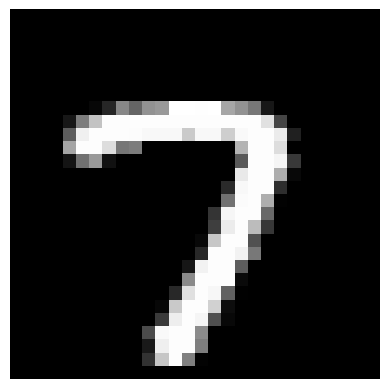

In [40]:
idx = np.random.randint(len(y_test))
plot_number(x_test_num[idx])
pred = predict(x_test[idx].reshape(-1,1))
print(f'El valor predicho es: {pred}')